# Spare-It POC: Synthetic Image Generator

In [1]:
import os
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from pycocotools.coco import COCO
from matplotlib import image
from PIL import Image
from scipy import ndimage
import math
from skimage import measure
from imantics import Polygons, Mask

In [2]:
# Methods for image cropping and masking
def crop(arr):
    objs = ndimage.find_objects(arr>0)
    if(len(objs) != 0):
        slice_x, slice_y = objs[0]
        return arr[slice_x, slice_y]
    return None
def cropc(arr):
    slice_x, slice_y, slice_z = ndimage.find_objects(arr>0)[0]
    return arr[slice_x, slice_y, slice_z]
def crop_coord(arr):
    slice_x, slice_y = ndimage.find_objects(arr>0)[0]
    return [slice_x, slice_y]
def apply_mask(image, mask):
    # Convert to numpy arrays
    mask = np.array(mask)
    # Convert grayscale image to RGB
    mask = np.stack((mask,)*3, axis=-1)
    # Multiply arrays
    resultant = image*mask
    return resultant

In [3]:
# Method for filenaming convention
# Finds current highest number filename in output directory and names the next file one more than it
def max_file(path):
    files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
    max = 0
    for f in files:
        s = f.split('.')
        if(int(s[0]) > max):
            max = int(s[0])
    return max + 1

In [4]:
# Method for sampling a normally distributed random variable for a given file dimension
def random_offset(dist):
    center = dist/2
    var = dist/10
    rand = math.ceil(np.random.normal(center, var, 1)[0])
    if(rand < dist/4 or rand > 3*dist/4):
        return math.ceil(center)
    else:
        return rand

In [5]:
def json_to_img(json):
    fname = json.split('/')[-1].split('.json')[0]
    dataset = json.split('/')[1]
    if(dataset == 'taco_transformed'):
        return './taco_transformed/taco_image/images/' + fname + '.jpg'
    if(dataset == 'original_dataset'):
        return './original_dataset/images/' + fname + '.jpeg'
    else:
        return None

In [6]:
# Copy Paste Method
# Takes a list containing lists with a name of a json file and the category ID to be used with that json
# It also takes a base json file
# The part of each file that has its relevant category ID is pasted as chunks onto the base image with random positioning
# Returns the augmented image, json file, and mask
def copypaste(files, file2):
    img_dir = './images' # Source of image files
    coco2=COCO(file2) # COCO filetype for base image
    img2 = coco2.imgs[0] # Base image as described in json file
    imgpath2 = json_to_img(file2)
    image2 = np.array(Image.open(os.path.join(imgpath2))) # Array representing base image
    cat_ids = coco2.getCatIds()
    anns_ids2 = coco2.getAnnIds(imgIds=img2['id'], catIds=cat_ids, iscrowd=None)
    anns2 = coco2.loadAnns(anns_ids2) # List of annotations for base image
    mask2 = np.zeros((img2['height'],img2['width']))
    
    for i in range(len(anns2)):
        # Iterates over annotations and adds them to the mask
        # Each pixel is the ID of the category from the annotations
        temp = coco2.annToMask(anns2[i])*anns2[i]['category_id']
        mask2 = np.where(temp != 0, temp, mask2)
        
    for i in files:
        # Iterates over each file in the list of jsons
        file1 = i[0]
        cid = i[1]
        coco1=COCO(file1) # COCO filetype for currently pasted image
        img1 = coco1.imgs[0]
        imgpath1 = json_to_img(file1)
        image1 = np.array(Image.open(os.path.join(imgpath1)))
        anns_ids1 = coco1.getAnnIds(imgIds=img1['id'], catIds=cat_ids, iscrowd=None)
        anns1 = coco1.loadAnns(anns_ids1)
        mask1 = np.zeros((img1['height'],img1['width']))
        
        for i in range(len(anns1)):
            temp = coco1.annToMask(anns1[i])*anns1[i]['category_id']
            mask1 = np.where(temp != 0, temp, mask1)

        # Crops the image and mask for the current file being pasted to only include the selected category
        paste = np.where(mask1 == cid, 1, 0)
        mask_cropped = crop(paste)*cid
        image_cropped = cropc(apply_mask(image1, paste))

        # Gets a random offset for the x and y coordinate based on the base image file dimensions
        x_offset=random_offset(img2['width'])
        y_offset=random_offset(img2['height'])

        # Nested for loops that go pixel by pixel to place the pasted chunk onto the base image
        # Iterates over the dimensions of where the chunk will be pasted
        # Increments track where in the pasted chunk the loop is
        y_inc = 0
        for i in range(y_offset,y_offset+image_cropped.shape[0]):
            x_inc = 0
            if(i < img2['height']): # Ensures that the chunk is not pasted outside of the base image bounds
                for j in range(x_offset,x_offset+image_cropped.shape[1]):
                    if(mask_cropped[y_inc, x_inc] != 0 and j < img2['width']):
                        image2[i, j, :] = image_cropped[y_inc, x_inc, :]
                        mask2[i,j] = mask_cropped[y_inc, x_inc] # The mask is also updated with the pasted chunk
                    x_inc +=1
            y_inc += 1
    filenum = max_file('./copy_paste/synthetic_images') # Generates serial number to be the name for all exported files 
    newImg = Image.fromarray(image2)
    newImg.save('./copy_paste/synthetic_images/' + str(filenum) + '.jpeg') # Exports augmented image
    np.save('./copy_paste/masks/' + str(filenum), mask2) # Saves augmented mask as numpy array
    annotations = get_annotations(mask2) # Converts mask to COCO format annotations
    # Copies and exports the original json file with the annotations section updated
    with open(file2, 'r+') as file:
        template = json.load(file) 
    template['annotations'] = annotations
    with open('./copy_paste/synthetic_jsons/' + str(filenum) + '.json', 'w') as f:
        json.dump(template, f, indent=4)

In [7]:
# Converts a mask with multiple IDs to a list of binary masks with the related ID kept in a list
def mask_to_binary(mask):
    vals = np.unique(mask)
    z_index = np.where(vals == 0)
    vals = np.delete(vals, z_index)
    n = len(vals)
    binaries = []
    for i in range(n):
        binary = np.zeros(np.shape(mask))
        binary = np.where(mask == vals[i], 1, 0)
        binaries.append(binary)
    return binaries, vals
# Converts a mask with multiple IDs to COCO format annotations
def get_annotations(mask):
    bins, cids = mask_to_binary(mask)
    n = len(cids)
    annotations = []
    inc = 0
    for i in range(n):
        polygons = Mask(bins[i]).polygons().segmentation # Generates polygonal sets of coordinates for the mask
        for j in range(len(polygons)):
            ann = {}
            ann['id'] = inc
            inc += 1
            ann['image_id'] = 0
            ann['category_id'] = int(cids[i])
            polygon = polygons[j]
            seg = [polygon]
            ann['segmentation'] = seg
            annotations.append(ann)
    return annotations
            



# Loads all files into dictionary of sets
files = [f for f in os.listdir('./original_dataset/cocojson/') if os.path.isfile(os.path.join('./original_dataset/cocojson/', f))]
with open('./original_dataset/cocojson/' + files[-1], 'r+') as file:
        template = json.load(file)
cats = template['categories']
categories = {}
for i in cats:
    categories[i['id']] = i['name']
files_by_id = {}
files_by_id2 = {}
files_taco = {}
for i in categories:
    files_by_id[i] = set()
    files_by_id2[i] = set()
    files_taco[i] = set()

inc = 0
for i in files:
    with open('./original_dataset/cocojson/' + i, 'r+') as file:
        temp = json.load(file)
    annList = temp['annotations']
    for j in annList:
        cid = j['category_id']
        if(cid in categories):
            cats = temp['categories']
            
            cset = files_by_id[cid]
            cset.add('./original_dataset/cocojson/' + i)
            files_by_id[cid] = cset
    inc += 1
    if(inc % 1000 == 0):
        print(inc)
# The second dictionary records only files with less than 3 annotations
inc = 0
for i in files:
    with open('./original_dataset/cocojson/' + i, 'r+') as file:
        temp = json.load(file)
    annList = temp['annotations']
    if(len(annList) < 3):
        for j in annList:
            cid = j['category_id']
            if(cid in categories):
                cats = temp['categories']
                
                cset = files_by_id2[cid]
                cset.add('./original_dataset/cocojson/' + i)
                files_by_id2[cid] = cset
    inc += 1
    if(inc % 1000 == 0):
        print(inc)

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000


In [8]:
# Taco
inc = 0
tfiles = [f for f in os.listdir('./taco_transformed/taco_json/') if os.path.isfile(os.path.join('./taco_transformed/taco_json/', f))]
for i in tfiles:
    with open('./taco_transformed/taco_json/' + i, 'r+') as file:
        temp = json.load(file)
    annList = temp['annotations']
    if(len(annList) < 3):
        for j in annList:
            cid = j['category_id']
            if(cid in categories):
                cats = temp['categories']
                
                cset = files_taco[cid]
                cset.add('./taco_transformed/taco_json/' + i)
                files_taco[cid] = cset
    inc += 1
    if(inc % 1000 == 0):
        print(inc)

1000


In [9]:
for i in files_by_id:
    cset = files_by_id[i]
    tset = files_taco[i]
    files_by_id[i] = cset.union(tset)

In [10]:
for i in files_by_id[1]:
    if './taco' in i:
        print(i)

./taco_transformed/taco_json/batch_15_000002.json
./taco_transformed/taco_json/batch_15_000077.json
./taco_transformed/taco_json/batch_2_000047.json
./taco_transformed/taco_json/batch_15_000083.json
./taco_transformed/taco_json/batch_11_000038.json
./taco_transformed/taco_json/batch_12_000001.json
./taco_transformed/taco_json/batch_1_000083.json
./taco_transformed/taco_json/batch_7_000031.json
./taco_transformed/taco_json/batch_8_000006.json
./taco_transformed/taco_json/batch_1_000003.json
./taco_transformed/taco_json/batch_6_000008.json
./taco_transformed/taco_json/batch_5_000035.json
./taco_transformed/taco_json/batch_1_000074.json
./taco_transformed/taco_json/batch_3_IMG_4857.json
./taco_transformed/taco_json/batch_11_000052.json
./taco_transformed/taco_json/batch_3_IMG_4854.json
./taco_transformed/taco_json/batch_7_000094.json
./taco_transformed/taco_json/batch_7_000053.json
./taco_transformed/taco_json/batch_11_000042.json
./taco_transformed/taco_json/batch_15_000037.json
./taco_t

In [10]:
ids2 = []
for i in files_by_id2:
    if(len(files_by_id2[i]) > 0):
        ids2.append(i)

In [42]:
poplist = []
for i in files_by_id:
    if(len(files_by_id[i]) == 0):
        poplist.append(i)
for i in poplist:
    files_by_id.pop(i)

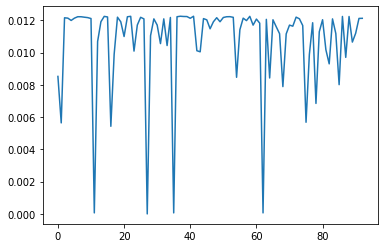

In [44]:
target = 0
for i in files_by_id:
    if(target < len(files_by_id[i])):
        target = len(files_by_id[i])
to_do = {}
for i in files_by_id:
    to_do[i] = target - len(files_by_id[i])
to_do[16] = 50
to_do[38] = 50
to_do[76] = 50
sum = 0
for i in to_do:
    sum += to_do[i]
probs = np.asarray(list(to_do.values()))/sum # inverse distribution
plt.plot(probs)

In [ ]:
# Generates copy paste images using inverse distribution 
# The output of this cell has been cleared to improve loading time in Github
def balance_sampling(probs, k):
    for i in range(k):
        appends = []
        for i in range(random.randint(1,30)):
            rid1 = random.choices(tuple(to_do), probs)[0]
            rfile1 = random.choice(tuple(files_by_id[rid1]))
            appends.append([rfile1, rid1])
        rfile2 = random.choice(tuple(files_by_id2[random.choice(ids2)]))
        try:
            copypaste(appends, rfile2)
        except:
            print("Error")
            print(appends)
            print(rfile2)
balance_sampling(probs, 10000)

In [12]:
chg = {}
for i in categories:
    chg[i] = set()
nfiles = [f for f in os.listdir('./copy_paste/synthetic_jsons/') if os.path.isfile(os.path.join('./copy_paste/synthetic_jsons/', f))]
for i in nfiles:
    with open('./copy_paste/synthetic_jsons/' + i, 'r+') as file:
        temp = json.load(file)
    annList = temp['annotations']
    for j in annList:
        cid = j['category_id']
        if(cid in categories):
            cats = temp['categories']

            cset = chg[cid]
            cset.add('./copy_paste/synthetic_jsons/' + i)
            chg[cid] = cset
y = {}
for i in categories:
    y[i] = 0
for i in chg:
    y[i] = 0
    sum = 0
    for j in chg[i]:
        with open(j, 'r+') as file:
            temp = json.load(file)
        annList = temp['annotations']
        for k in annList:
            y[k['category_id']] = y[k['category_id']] + 1

<BarContainer object of 100 artists>

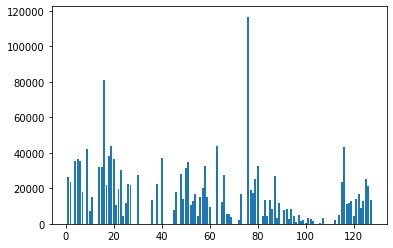

In [14]:
plt.bar(y.keys(), y.values())

In [20]:
sorted(y.items(), key=lambda item: item[1])

[(8, 0),
 (43, 0),
 (44, 0),
 (47, 0),
 (70, 0),
 (109, 0),
 (110, 0),
 (106, 636),
 (100, 720),
 (96, 907),
 (103, 1756),
 (98, 1770),
 (72, 1990),
 (112, 2328),
 (99, 2389),
 (93, 2749),
 (102, 2750),
 (88, 2991),
 (101, 3000),
 (107, 3298),
 (69, 3694),
 (82, 4168),
 (84, 4245),
 (24, 4280),
 (120, 4351),
 (95, 4403),
 (55, 4645),
 (114, 4851),
 (97, 5062),
 (68, 5499),
 (67, 5795),
 (10, 7322),
 (45, 7788),
 (91, 8047),
 (94, 8088),
 (86, 8342),
 (92, 8455),
 (123, 9041),
 (60, 9254),
 (52, 10525),
 (21, 10688),
 (117, 11432),
 (25, 11443),
 (89, 11765),
 (118, 11921),
 (65, 12410),
 (124, 12606),
 (119, 12653),
 (53, 12933),
 (36, 13154),
 (127, 13408),
 (85, 13670),
 (83, 13681),
 (49, 13867),
 (121, 14131),
 (56, 15170),
 (11, 15264),
 (59, 15353),
 (54, 16547),
 (73, 16889),
 (122, 17035),
 (78, 17150),
 (7, 17703),
 (46, 18106),
 (77, 19208),
 (22, 19328),
 (57, 19909),
 (126, 21189),
 (17, 21723),
 (27, 22042),
 (38, 22180),
 (26, 22656),
 (2, 23346),
 (115, 23490),
 (125, 25

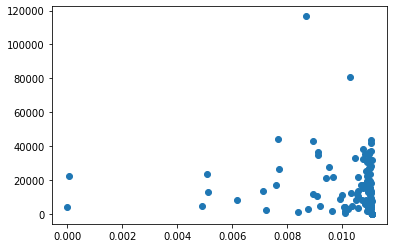

In [13]:
plt.scatter(probs, y.values())

In [22]:
y1 = {}
y1[128] = 0
y1[129] = 0
y1[-1] = 0
for i in categories:
    y1[i] = 0
for i in files_by_id:
    y1[i] = 0
    sum = 0
    for j in files_by_id[i]:
        with open(j, 'r+') as file:
            temp = json.load(file)
        annList = temp['annotations']
        for k in annList:
            y1[k['category_id']] = y1[k['category_id']] + 1

<BarContainer object of 100 artists>

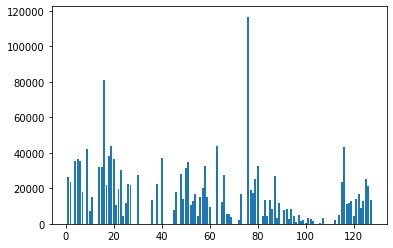

In [23]:
plt.bar(y.keys(), y.values())

<BarContainer object of 103 artists>

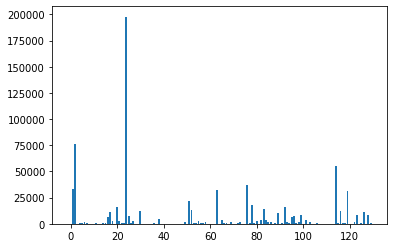

In [24]:
plt.bar(y1.keys(), y1.values())

<BarContainer object of 100 artists>

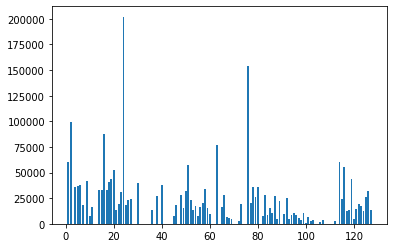

In [25]:
s = {}
for i in y:
    s[i] = y[i] + y1[i]
plt.bar(s.keys(), s.values())

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


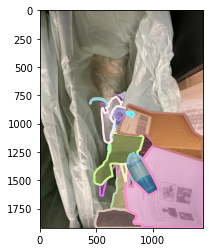

In [36]:
num = 1405
tj = './copy_paste/synthetic_jsons/' + str(num) + '.json'
ti = np.array(Image.open(os.path.join('./copy_paste/synthetic_images/' + str(num) + '.jpeg')))
plt.imshow(ti)
coco=COCO(tj)
catIds = coco.getCatIds()
cats = coco.loadCats(catIds)
ids = coco.getAnnIds()
cat_ids = coco.getCatIds()
img = coco.imgs[0]
anns_ids = coco.getAnnIds(imgIds=img['id'], catIds=cat_ids, iscrowd=None)
anns = coco.loadAnns(anns_ids)
coco.showAnns(anns)